In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r'C:\Users\User\OneDrive\Desktop\all_in_one\traditional_ML\regression\student_performamce\student_performance_dirty.csv'
df = pd.read_csv(file_path)

In [3]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Notes
0,7.0,99,Yes,9.0,1,91.0,excellent
1,4.0,82,No,4.0,2,65.0,review
2,8.0,51,Yes,7.0,2,45.0,review
3,5.0,52,Yes,5.0,2,36.0,excellent
4,7.0,75,No,8.0,5,66.0,review
...,...,...,...,...,...,...,...
10000,5.0,69,No,8.0,2,51.0,excellent
10001,2.0,46,Yes,4.0,8,20.0,review
10002,7.0,56,Yes,7.0,5,46.0,excellent
10003,NaN,42,Yes,8.0,5,28.0,review


In [3]:
df.isna().sum()

Hours Studied                       1032
Previous Scores                        0
Extracurricular Activities             0
Sleep Hours                          496
Sample Question Papers Practiced       0
Performance Index                      0
Notes                                  0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     8973 non-null   float64
 1   Previous Scores                   10005 non-null  int64  
 2   Extracurricular Activities        10005 non-null  object 
 3   Sleep Hours                       9509 non-null   float64
 4   Sample Question Papers Practiced  10005 non-null  int64  
 5   Performance Index                 10005 non-null  float64
 6   Notes                             10005 non-null  object 
dtypes: float64(3), int64(2), object(2)
memory usage: 547.3+ KB


In [5]:
names_to_map = {
    "Hours Studied":"hours_studied",
    "Previous Scores": "previous_scores",
    "Extracurricular Activities": "extracurricular_activities",
    "Sleep Hours":"sleep_hours",
    "Sample Question Papers Practiced": "smaple_question_papers_particed",
    "Performance Index":"performance_index",
    "Notes": "notes"
}

df = df.rename(columns=names_to_map)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   hours_studied                    8973 non-null   float64
 1   previous_scores                  10005 non-null  int64  
 2   extracurricular_activities       10005 non-null  object 
 3   sleep_hours                      9509 non-null   float64
 4   smaple_question_papers_particed  10005 non-null  int64  
 5   performance_index                10005 non-null  float64
 6   notes                            10005 non-null  object 
dtypes: float64(3), int64(2), object(2)
memory usage: 547.3+ KB


In [6]:
null_columns = df.columns[df.isna().any()].tolist()
null_columns

['hours_studied', 'sleep_hours']

In [7]:
categories_to_map = {
    "Yes":1,
    "No":0,
    "excellent":1,
    "review":0
}

columns_to_map = ['extracurricular_activities', 'notes']
for col in columns_to_map:
    df[col] = df[col].map(categories_to_map)

In [8]:
df.corr()['hours_studied']

hours_studied                      1.000000
previous_scores                   -0.014961
extracurricular_activities        -0.004228
sleep_hours                        0.008612
smaple_question_papers_particed    0.018450
performance_index                  0.373058
notes                              0.004216
Name: hours_studied, dtype: float64

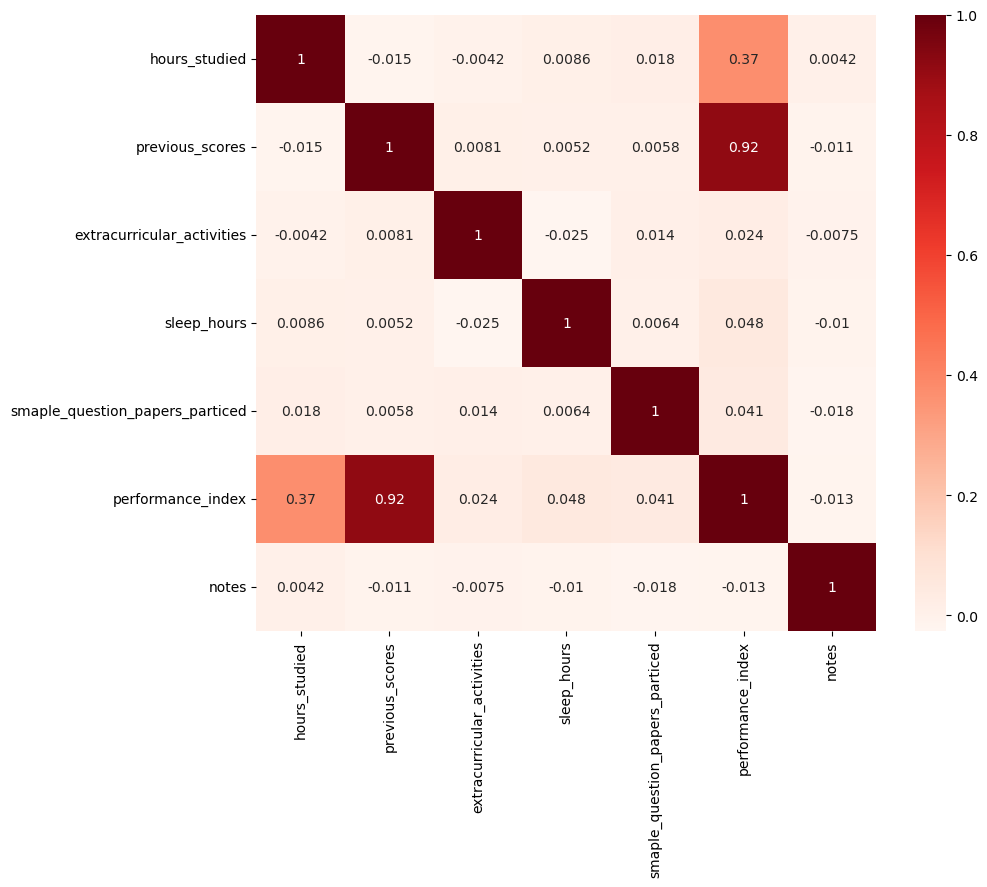

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="Reds",annot= True)
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

train_data = df.dropna(subset=['hours_studied'])

model = LinearRegression()
model.fit(train_data[['performance_index']], train_data['hours_studied'])

missing = df['hours_studied'].isna()
df.loc[missing, 'hours_studied'] = model.predict(df.loc[missing, ['performance_index']])

In [13]:
df['hours_studied'] = df['hours_studied'].round().astype(int)

In [14]:
df.corr()['sleep_hours']

hours_studied                      0.008826
previous_scores                    0.005209
extracurricular_activities        -0.025401
sleep_hours                        1.000000
smaple_question_papers_particed    0.006361
performance_index                  0.048368
notes                             -0.010296
Name: sleep_hours, dtype: float64

In [15]:
df.groupby(by=['extracurricular_activities'])['sleep_hours'].median()

extracurricular_activities
0    7.0
1    6.0
Name: sleep_hours, dtype: float64

In [16]:
df.groupby(by=['extracurricular_activities'])['sleep_hours'].mean()

extracurricular_activities
0    6.571756
1    6.485556
Name: sleep_hours, dtype: float64

In [17]:
df['sleep_hours'] = df['sleep_hours'].fillna(
    df.groupby('extracurricular_activities')['sleep_hours'].transform('median')
)

In [18]:
df

,hours_studied,previous_scores,extracurricular_activities,sleep_hours,smaple_question_papers_particed,performance_index,notes
0,7,99,1,9.0,1,91.0,1
1,4,82,0,4.0,2,65.0,0
2,8,51,1,7.0,2,45.0,0
3,5,52,1,5.0,2,36.0,1
4,7,75,0,8.0,5,66.0,0
...,...,...,...,...,...,...,...
10000,5,69,0,8.0,2,51.0,1
10001,2,46,1,4.0,8,20.0,0
10002,7,56,1,7.0,5,46.0,1
10003,4,42,1,8.0,5,28.0,0


#### Outliers

In [19]:
from scipy.stats import zscore

z_scores = df.select_dtypes(include=['number']).apply(zscore)  
outliers = (z_scores.abs() > 3)  
df_outliers = df[outliers.any(axis=1)] 

In [20]:
df_outliers

,hours_studied,previous_scores,extracurricular_activities,sleep_hours,smaple_question_papers_particed,performance_index,notes
1327,2,49,0,6.0,27,26.0,1
1598,5,78,1,6.0,27,59.0,1
7171,9,46,1,8.0,27,39.0,1


In [21]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df < lower_bound) | (df > upper_bound)
df_outliers = df[outliers.any(axis=1)]

In [22]:
df_outliers

,hours_studied,previous_scores,extracurricular_activities,sleep_hours,smaple_question_papers_particed,performance_index,notes
1327,2,49,0,6.0,27,26.0,1
1598,5,78,1,6.0,27,59.0,1
7171,9,46,1,8.0,27,39.0,1


In [23]:
df.drop(index=[1327,1598,7171],inplace=True)

#### Modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.ensemble import GradientBoostingRegressor

In [25]:
X,y = df.drop(['performance_index'],axis=1), df['performance_index'].copy()

In [26]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [27]:
X_train.shape,y_train.shape, X_test.shape,y_test.shape

((8001, 6), (8001,), (2001, 6), (2001,))

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics(model,test,y_test):

    y_pred = model.predict(test)

    mse = round(mean_squared_error(y_test,y_pred),1)
    rmse = round(np.sqrt(mse),1)
    mae = round(mean_absolute_error(y_test,y_pred),1)
    r2 = round(r2_score(y_test,y_pred),2)

    print(f'MAE: {mae}, MSE: {mse}, RMSE: {rmse}, r2_Score: {r2}')

In [30]:
lin_reg = LinearRegression()
linear_svr = LinearSVR()
rnd_clf_reg = RandomForestRegressor(random_state=42)
grd_boost_reg = GradientBoostingRegressor(random_state=42)

models = [lin_reg,linear_svr,rnd_clf_reg,grd_boost_reg]


for model in models:
    model.fit(X_train_scaled, y_train)
    print(f'{type(model).__name__}\'s metrics:')
    metrics(model,X_test_scaled,y_test)
    print()

LinearRegression's metrics:
MAE: 2.1, MSE: 8.8, RMSE: 3.0, r2_Score: 0.98

LinearSVR's metrics:
MAE: 2.1, MSE: 8.8, RMSE: 3.0, r2_Score: 0.98

RandomForestRegressor's metrics:
MAE: 2.4, MSE: 10.2, RMSE: 3.2, r2_Score: 0.97

GradientBoostingRegressor's metrics:
MAE: 2.2, MSE: 8.3, RMSE: 2.9, r2_Score: 0.98



In [31]:
metrics_data = {
    'Model': ['LinearRegression', 'LinearSVR', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'MAE': [2.1, 2.1, 2.4, 2.2],
    'MSE': [8.8, 8.8, 10.2, 8.3],
    'RMSE': [3.0, 3.0, 3.2, 2.9],
    'R² Score': [0.98, 0.98, 0.97, 0.98]
}

metrics_df = pd.DataFrame(metrics_data)

metrics_df

,Model,MAE,MSE,RMSE,R² Score
0,LinearRegression,2.1,8.8,3.0,0.98
1,LinearSVR,2.1,8.8,3.0,0.98
2,RandomForestRegressor,2.4,10.2,3.2,0.97
3,GradientBoostingRegressor,2.2,8.3,2.9,0.98
